In [21]:
# Import your existing types and functions
from pathlib import Path

import pandas as pd
import torch
from js_embedding_vis import write_inlined_config
from muutils.collect_warnings import CollateWarnings

from spd.analysis.embed_vis import AnalysisConfig, coactivation_analysis, plot_embedding_label_grid
from spd.analysis.grouping import (
    CoactivationResults,
	CoactivationResultsGroup,
    get_coactivations,
)
from spd.data_utils import SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.utils import get_device

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE = get_device()
torch.set_grad_enabled(False)
print(f"Using device: {DEVICE = }")

Using device: DEVICE = 'cuda'


In [ ]:
def clustering_pipeline(
        name: str,
		coactivations: CoactivationResultsGroup,
        analysis_config: AnalysisConfig = AnalysisConfig( # noqa: B008
            embedding_configs={
                "isomap": {"n_neighbors": [2, 4, 8, 16, 32, 64, 128]},
                # "umap": {"n_neighbors": [2, 8, 32, 128]},
                # "tsne": {"perplexity": [5, 10, 20, 30, 50]},
            },
            clustering_configs={
                # "kmeans": {"n_clusters": [3, 5, 8, 10, 15, 20]},
                # "agglomerative": {"n_clusters": [3, 5, 8, 10, 15, 20]},
                # "spectral": {"n_clusters": [3, 5, 8, 10, 15, 20]},
                # "dbscan": {"eps": [0.05, 0.1, 0.2, 0.3, 0.5]},
                # "optics": {"min_samples": [3, 5, 10, 20]},
                "kmeans": {"n_clusters": [4]},
                "agglomerative": {"n_clusters": [4]},
                # "spectral": {"n_clusters": [4]},
                # "optics": {"min_samples": [4]},
            },
            n_components=3,
        ),
    ) -> pd.DataFrame:

    df: pd.DataFrame
    with CollateWarnings(fmt="({count}x) {filename}:{lineno}\n  {category}: {message}"):
        df, metadata = coactivation_analysis(
            group=coactivations,
            config=analysis_config,
        )

    # Print structure
    print(metadata.describe())

    # plot embedding label grid
    plot_embedding_label_grid(
        df,
        metadata,
        figsize_per_cell=(4,4),
        point_size=128,
    )


    out_path: Path = Path(f"../display/embedvis-{name}.html")
    write_inlined_config(
        cfg=dict(
            dataFile=None,
            data=df.to_dict(orient="records"),
            numericalPrefix="embed.isomap.n_neighbors-064.ax.",
            defaultColorColumn="feat.class.hclust",
            defaultSelectionColumn="feat.class.hclust",
            hoverColumns=[
                "feat.class.hclust",
                "feat.activation_freq",
            ],
        ),
        out_path=out_path,
    )
    print(f"wrote interactive display to {out_path}")

    return df

[ /home/miv/projects/MATS/apd/spd/analysis/embedding.py:163 ] jac: μ=0.00 σ=0.04 x̃=0.00 R=[0.00,1.00] ℙ˪=|█▄▃▃▂▁▃| shape=(400,400) dtype=torch.float32 device=cpu ∇✗
[ /home/miv/projects/MATS/apd/spd/analysis/embedding.py:170 ] dist: μ=1.00 σ=0.02 x̃=1.00 R=[0.50,1.00] ℙ˪=|▃▂▃▃▃▅█| shape=(400,400) dtype=torch.float32 device=cpu ∇✗


Starting coactivation analysis...
Computing hierarchical clustering...
Working with 113 alive features out of 400 total
Computing isomap embeddings...


(1x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384
(34x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/scipy/sparse/_index.py:168
(2x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384


Computing clustering on embeddings...
Analysis complete! DataFrame shape: (78, 35)
Column groups: ['feat(4)', 'embed(18)', 'feat.class(13)']
Analysis df with 400 features (113 alive)

Column Groups:
  feat: 4 columns
    ['feat.alive', 'feat.activation_freq', 'feat.activation_freq_log', 'feat.module']
  embed: 18 columns
    ['embed.isomap.n_neighbors-002.ax.0', 'embed.isomap.n_neighbors-002.ax.1', 'embed.isomap.n_neighbors-002.ax.2', 'embed.isomap.n_neighbors-004.ax.0', 'embed.isomap.n_neighbors-004.ax.1'] ... ['embed.isomap.n_neighbors-064.ax.1', 'embed.isomap.n_neighbors-064.ax.2']
  feat.class: 13 columns
    ['feat.class.hclust', 'feat.class.isomap.n_neighbors-002.kmeans.n_clusters-004', 'feat.class.isomap.n_neighbors-002.agglomerative.n_clusters-004', 'feat.class.isomap.n_neighbors-004.kmeans.n_clusters-004', 'feat.class.isomap.n_neighbors-004.agglomerative.n_clusters-004'] ... ['feat.class.isomap.n_neighbors-064.kmeans.n_clusters-004', 'feat.class.isomap.n_neighbors-064.agglomer

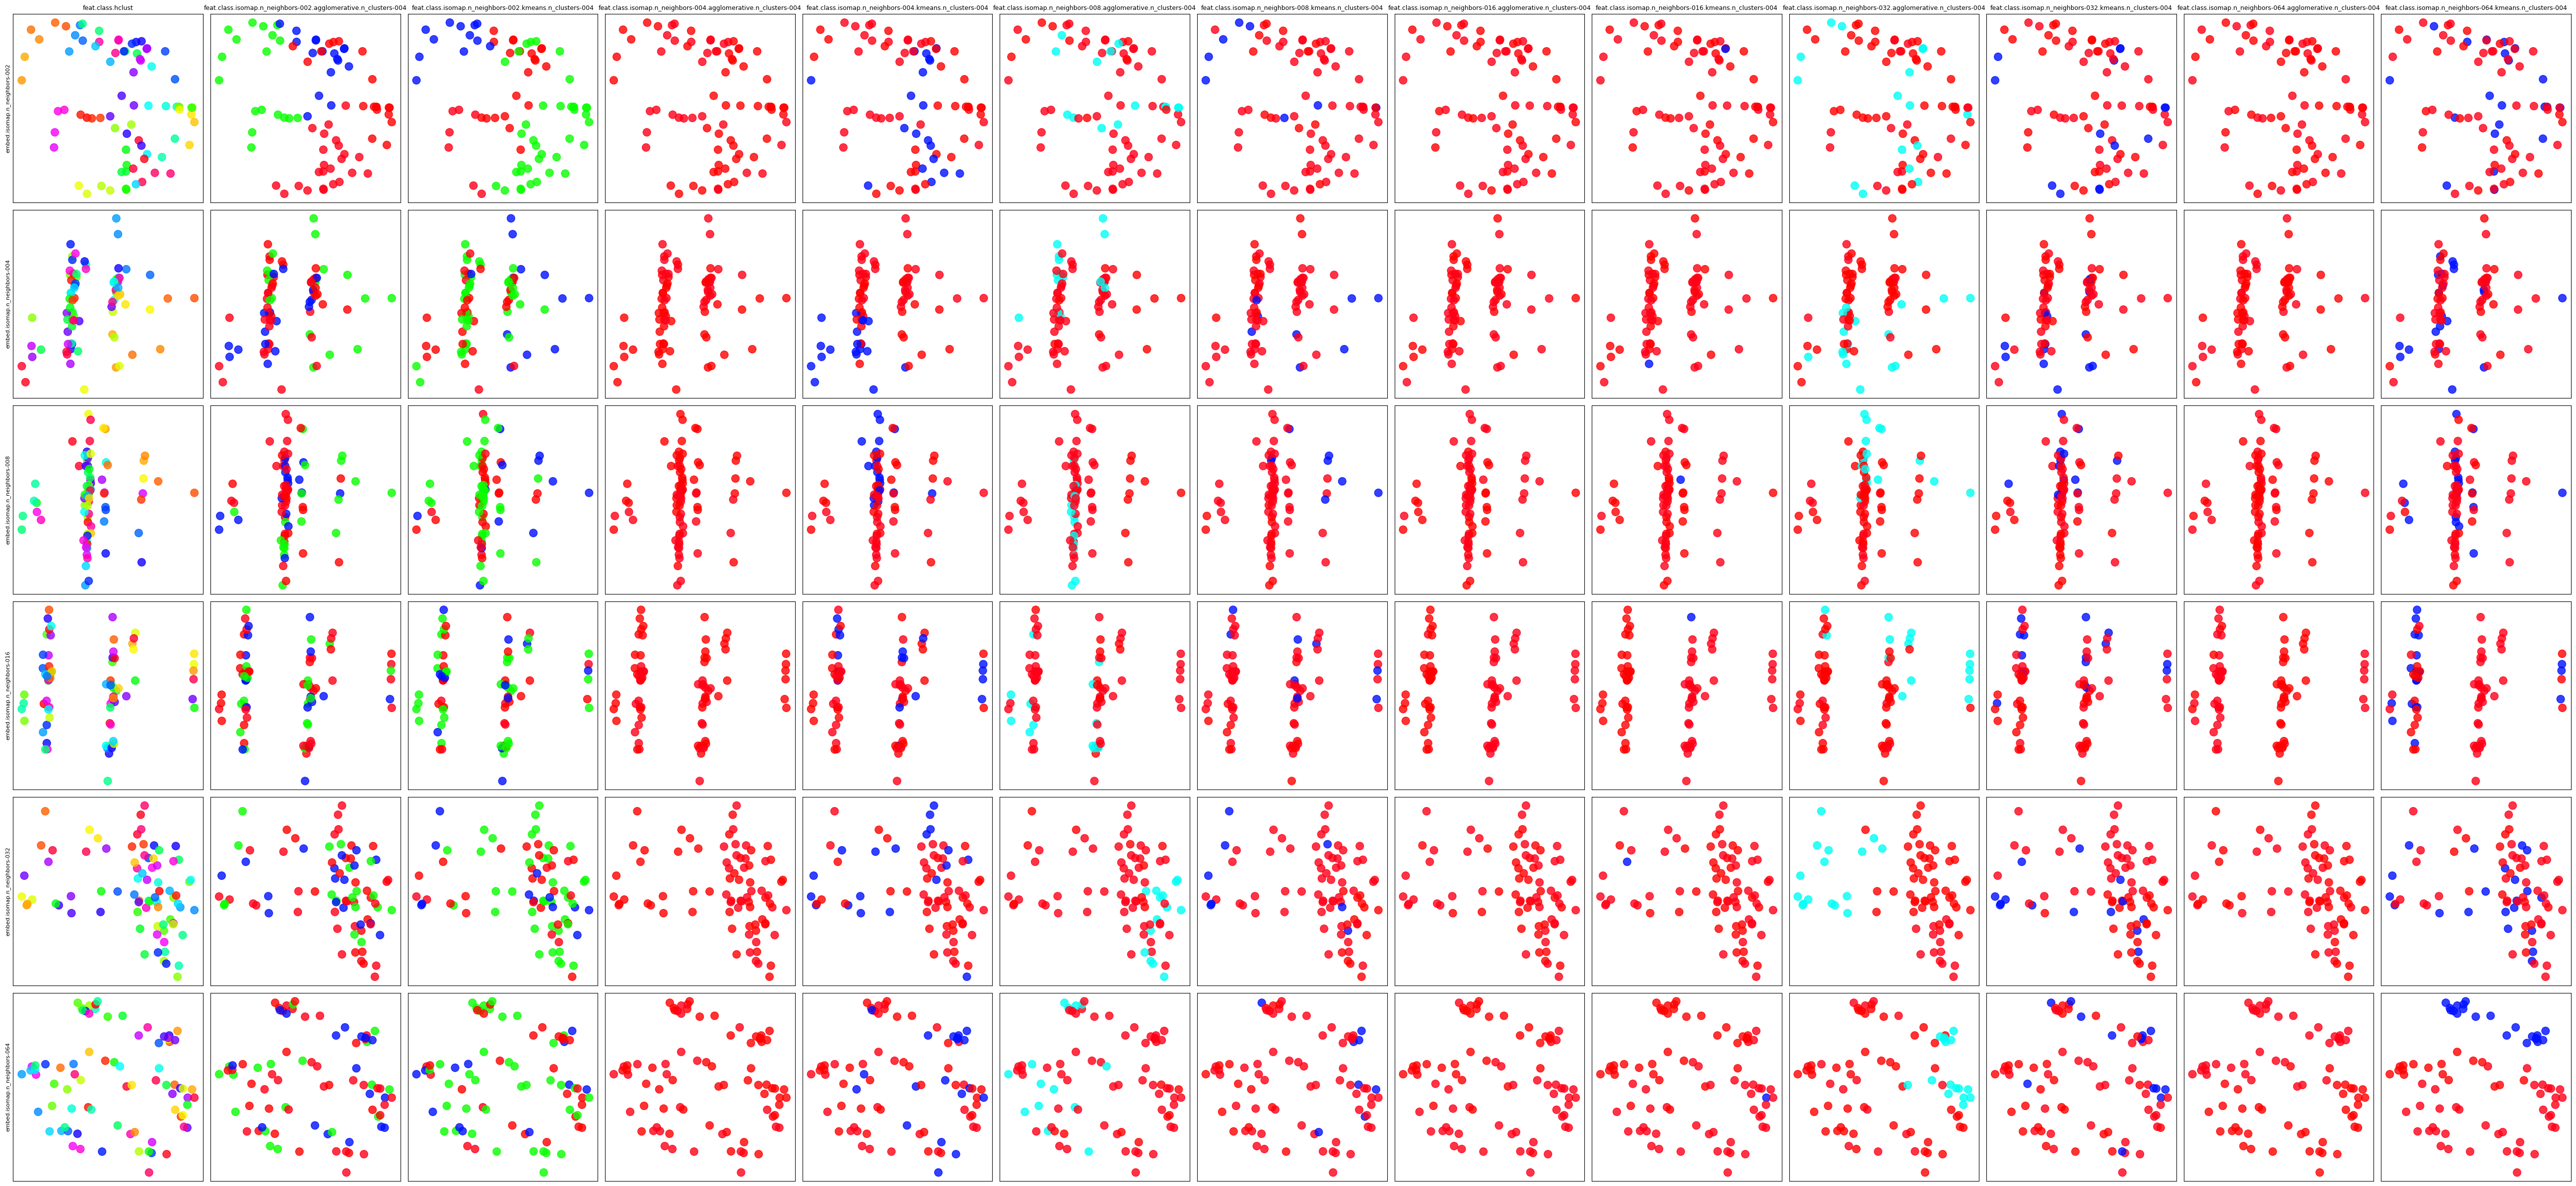

wrote interactive display to ../display/embedvis-tms.html


In [20]:
clustering_pipeline(
	name="tms",
	coactivations=get_coactivations(
		model_path=Path("../data/tms-decomp/model_40000.pth"),
		dataset_cls=SparseFeatureDataset,
		dataset_kwargs=dict(
			value_range=(0.0, 1.0),
			synced_inputs=None,
		),
		coactivations_kwargs=dict(
			module_groups=[["linear1", "linear2"]],
		),
		device=DEVICE,
	)["group_0"],
);

[ /home/miv/projects/MATS/apd/spd/analysis/embedding.py:163 ] jac: μ=0.02 σ=0.08 x̃=0.00 R=[0.00,1.00] ℙ˪=|█▆▁   ▄| shape=(200,200) dtype=torch.float32 device=cpu ∇✗
[ /home/miv/projects/MATS/apd/spd/analysis/embedding.py:170 ] dist: μ=0.98 σ=0.05 x̃=1.00 R=[0.50,1.00] ℙ˪=|▄  ▂▆▃█| shape=(200,200) dtype=torch.float32 device=cpu ∇✗


Starting coactivation analysis...
Computing hierarchical clustering...
Working with 150 alive features out of 200 total
Computing isomap embeddings...
Computing clustering on embeddings...
Analysis complete! DataFrame shape: (150, 40)
Column groups: ['feat(4)', 'embed(21)', 'feat.class(15)']
Analysis df with 200 features (150 alive)

Column Groups:
  feat: 4 columns
    ['feat.alive', 'feat.activation_freq', 'feat.activation_freq_log', 'feat.module']
  embed: 21 columns
    ['embed.isomap.n_neighbors-002.ax.0', 'embed.isomap.n_neighbors-002.ax.1', 'embed.isomap.n_neighbors-002.ax.2', 'embed.isomap.n_neighbors-004.ax.0', 'embed.isomap.n_neighbors-004.ax.1'] ... ['embed.isomap.n_neighbors-128.ax.1', 'embed.isomap.n_neighbors-128.ax.2']
  feat.class: 15 columns
    ['feat.class.hclust', 'feat.class.isomap.n_neighbors-002.kmeans.n_clusters-004', 'feat.class.isomap.n_neighbors-002.agglomerative.n_clusters-004', 'feat.class.isomap.n_neighbors-004.kmeans.n_clusters-004', 'feat.class.isomap.n_

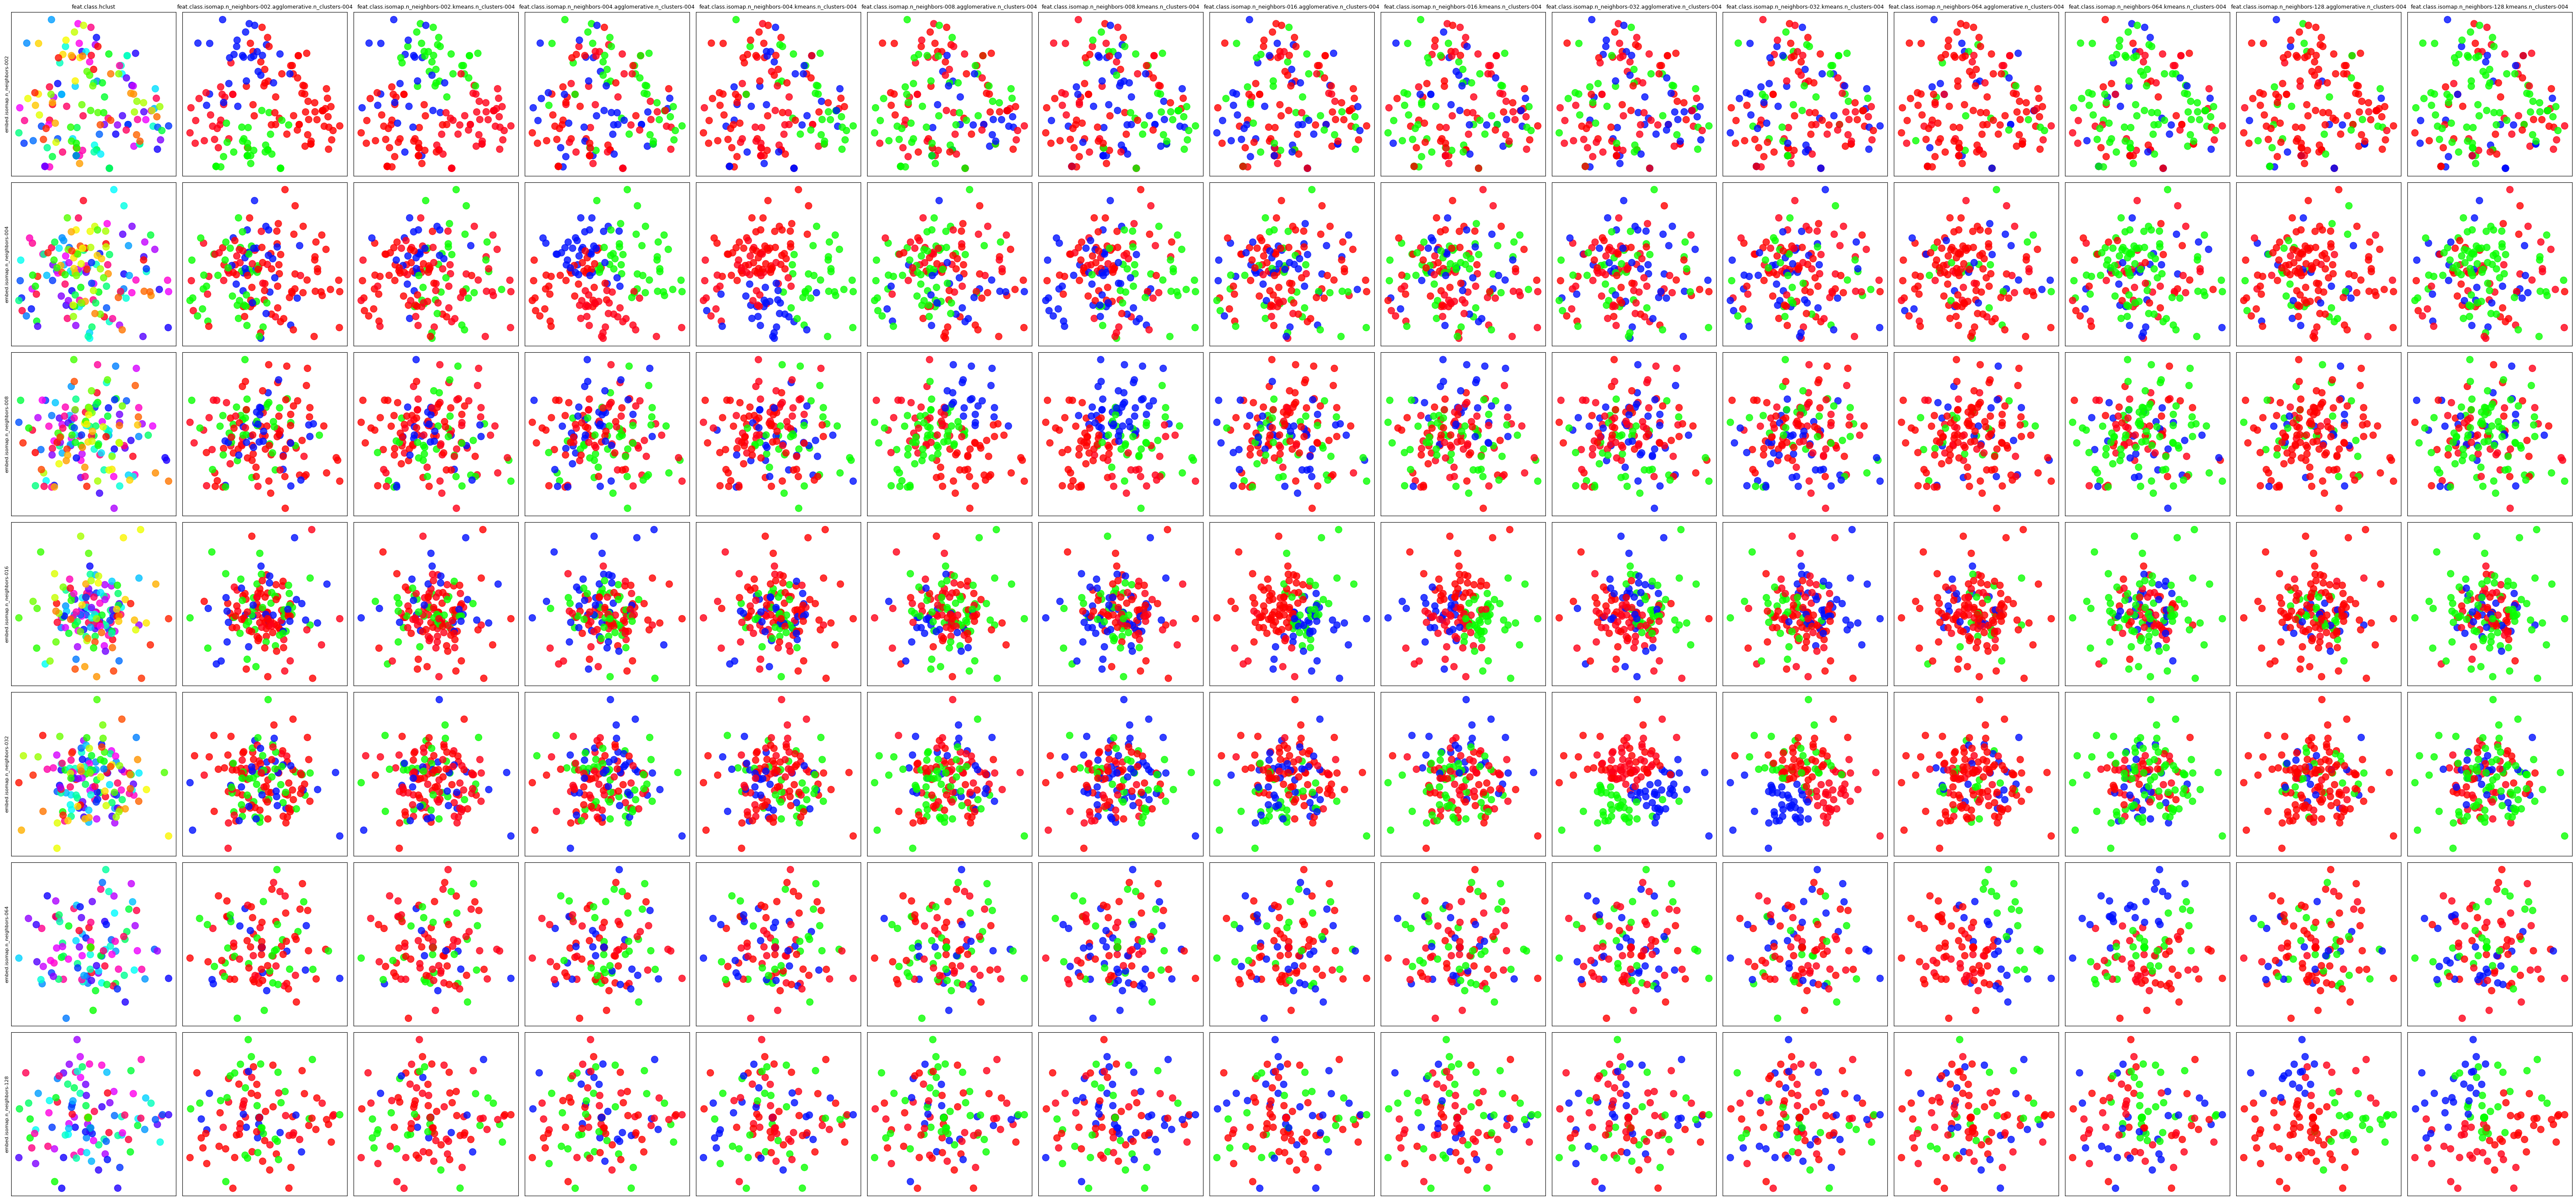

wrote interactive display to ../display/embedvis-mlp.html


In [22]:
clustering_pipeline(
	name="mlp",
	coactivations=get_coactivations(
		model_path=Path("../data/mlp-decomp/model_30000.pth"),
		dataset_cls=ResidualMLPDataset,
		dataset_kwargs=dict(
			calc_labels=False,  # Our labels will be the output of the target model
			label_type=None,
			act_fn_name=None,
			label_fn_seed=None,
			label_coeffs=None,
			synced_inputs=None,
		),
		coactivations_kwargs=dict(
			module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
		),
		device=DEVICE,
	)["group_0"],
);